# 03 – Policy Tradeoffs and Insights

This notebook investigates policy tradeoffs between total costs and expected deaths, identifying low-cost and high-cost policies, and analyzing lever settings behind them.


## Load and Merge Results
We load the `.tar.gz` result file and merge experiments with outcomes.


In [5]:
from ema_workbench import load_results
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

def load_combined_data(filepath):
    experiments, outcomes = load_results(filepath)
    experiments_df = pd.DataFrame(experiments)
    outcomes_df = pd.DataFrame(outcomes)
    combined_df = pd.concat([experiments_df.reset_index(drop=True),
                             outcomes_df.reset_index(drop=True)], axis=1)
    return experiments_df, outcomes_df, combined_df

# Call function
experiments_df, outcomes_df, combined_df = load_combined_data('ema_resultsprobstate3.tar.gz')


## 2. Define Fixed Policy Levers
We use an explicit list of policy levers (not inferred) to avoid pulling in outcomes like total cost.


In [6]:
policy_levers = [
    '0_RfR 0', '0_RfR 1', '0_RfR 2', '1_RfR 0', '1_RfR 1', '1_RfR 2',
    '2_RfR 0', '2_RfR 1', '2_RfR 2', '3_RfR 0', '3_RfR 1', '3_RfR 2',
    '4_RfR 0', '4_RfR 1', '4_RfR 2',
    'A.1_DikeIncrease 0', 'A.1_DikeIncrease 1', 'A.1_DikeIncrease 2',
    'A.2_DikeIncrease 0', 'A.2_DikeIncrease 1', 'A.2_DikeIncrease 2',
    'A.3_DikeIncrease 0', 'A.3_DikeIncrease 1', 'A.3_DikeIncrease 2',
    'A.4_DikeIncrease 0', 'A.4_DikeIncrease 1', 'A.4_DikeIncrease 2',
    'A.5_DikeIncrease 0', 'A.5_DikeIncrease 1', 'A.5_DikeIncrease 2',
    'EWS_DaysToThreat'
]


## 3. Summarize Mean Costs Per Policy
Aggregate by policy and calculate average costs and fixed lever settings.


In [7]:
def summarize_costs_by_policy(df, cost_col, lever_list):
    summary = df.groupby('policy').agg(
        mean_costs=(cost_col, 'mean'),
        **{lever: (lever, 'first') for lever in lever_list}
    ).reset_index()
    summary['policy_id'] = summary[lever_list].astype(str).agg('-'.join, axis=1)
    return summary

# Call function
costs_col = "A.5 Total Costs"
policy_summary_costs = summarize_costs_by_policy(combined_df, costs_col, policy_levers)


/var/folders/64/05z9tvhd1mn8h92shl8zdmwr0000gn/T/ipykernel_94768/126580906.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('policy').agg(


## 4. Plot Lowest Cost Policies
Visualize the top 50 lowest-cost policies with bar plots.


In [8]:
def plot_cost_policies(df, y_col, title):
    fig = px.bar(
        df,
        x='policy_id',
        y=y_col,
        hover_data=policy_levers + ['policy'],
        color=y_col,
        color_continuous_scale='Viridis',
        title=title,
        labels={'policy_id': 'Policy Combination', y_col: y_col}
    )
    fig.update_layout(
        xaxis_tickangle=45,
        xaxis_title="Policy (DikeIncrease - RfR - EWS)",
        yaxis_title=y_col,
        width=900,
        height=600
    )
    fig.show()

# Call function
top_policies_costs = policy_summary_costs.nsmallest(50, 'mean_costs')
plot_cost_policies(top_policies_costs, 'mean_costs', "Top 50 Policies with Lowest Mean Total Costs")


## 5. Plot Highest Cost Policies
Same analysis for the most expensive policies.


In [9]:
high_cost_policies = policy_summary_costs.nlargest(50, 'mean_costs')
plot_cost_policies(high_cost_policies, 'mean_costs', "Top 50 Policies with Highest Mean Total Costs")


## 6. Extract DataFrames for Summary Statistics
We prepare DataFrames for further statistical and visual analysis.


In [10]:
final_df_costs = top_policies_costs[['policy', 'mean_costs'] + policy_levers].sort_values('mean_costs').reset_index(drop=True)
final_df_high_costs = high_cost_policies[['policy', 'mean_costs'] + policy_levers].sort_values('mean_costs').reset_index(drop=True)


## 7. Summary Statistics and Boxplots
Show lever distributions, common values, and constant levers.


--- Lowest Cost Policies: Summary Statistics ---
                    count  mean       std  min   25%  50%   75%   max
0_RfR 0              50.0  0.60  0.494872  0.0  0.00  1.0  1.00   1.0
0_RfR 1              50.0  0.62  0.490314  0.0  0.00  1.0  1.00   1.0
0_RfR 2              50.0  0.46  0.503457  0.0  0.00  0.0  1.00   1.0
1_RfR 0              50.0  0.44  0.501427  0.0  0.00  0.0  1.00   1.0
1_RfR 1              50.0  0.38  0.490314  0.0  0.00  0.0  1.00   1.0
1_RfR 2              50.0  0.44  0.501427  0.0  0.00  0.0  1.00   1.0
2_RfR 0              50.0  0.50  0.505076  0.0  0.00  0.5  1.00   1.0
2_RfR 1              50.0  0.42  0.498569  0.0  0.00  0.0  1.00   1.0
2_RfR 2              50.0  0.38  0.490314  0.0  0.00  0.0  1.00   1.0
3_RfR 0              50.0  0.74  0.443087  0.0  0.25  1.0  1.00   1.0
3_RfR 1              50.0  0.62  0.490314  0.0  0.00  1.0  1.00   1.0
3_RfR 2              50.0  0.66  0.478518  0.0  0.00  1.0  1.00   1.0
4_RfR 0              50.0  0.50  0.505076

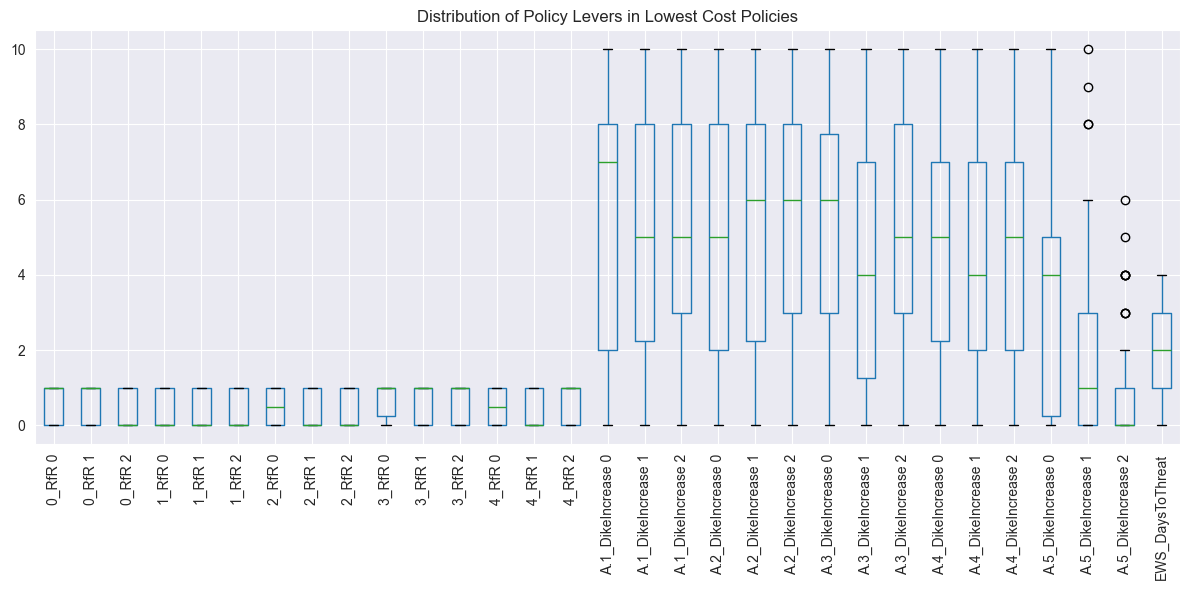

--- Highest Cost Policies: Summary Statistics ---
                    count  mean       std  min   25%  50%    75%   max
0_RfR 0              50.0  0.52  0.504672  0.0  0.00  1.0   1.00   1.0
0_RfR 1              50.0  0.40  0.494872  0.0  0.00  0.0   1.00   1.0
0_RfR 2              50.0  0.44  0.501427  0.0  0.00  0.0   1.00   1.0
1_RfR 0              50.0  0.46  0.503457  0.0  0.00  0.0   1.00   1.0
1_RfR 1              50.0  0.52  0.504672  0.0  0.00  1.0   1.00   1.0
1_RfR 2              50.0  0.48  0.504672  0.0  0.00  0.0   1.00   1.0
2_RfR 0              50.0  0.46  0.503457  0.0  0.00  0.0   1.00   1.0
2_RfR 1              50.0  0.40  0.494872  0.0  0.00  0.0   1.00   1.0
2_RfR 2              50.0  0.50  0.505076  0.0  0.00  0.5   1.00   1.0
3_RfR 0              50.0  0.36  0.484873  0.0  0.00  0.0   1.00   1.0
3_RfR 1              50.0  0.50  0.505076  0.0  0.00  0.5   1.00   1.0
3_RfR 2              50.0  0.50  0.505076  0.0  0.00  0.5   1.00   1.0
4_RfR 0              50.0  

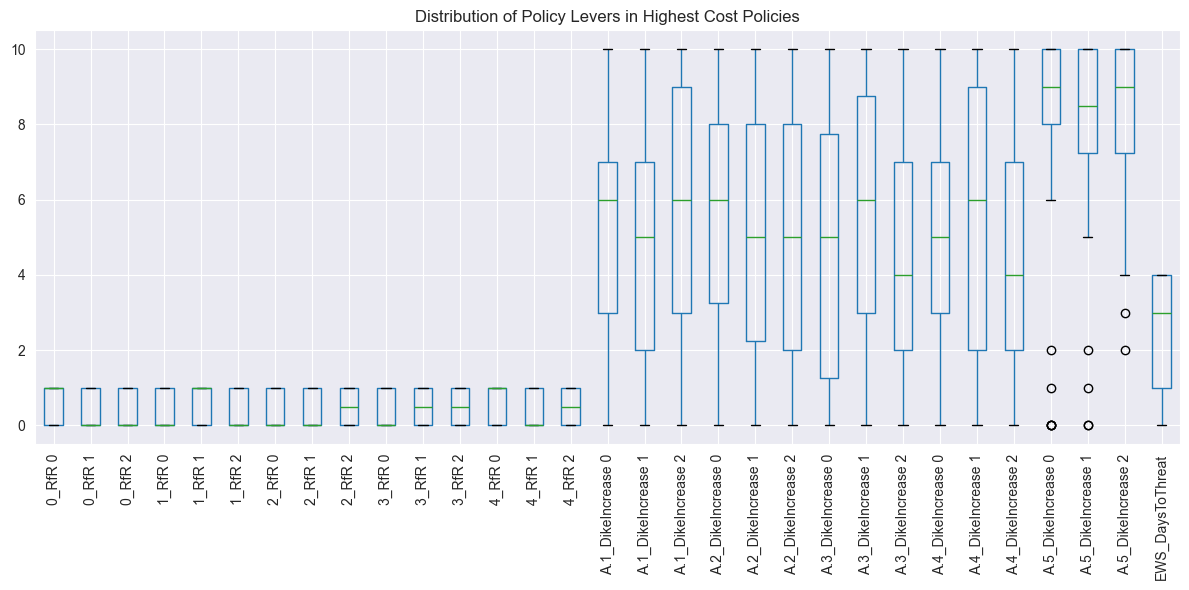

In [11]:
def summarize_and_plot_levers(df, title):
    print(f"--- {title}: Summary Statistics ---")
    print(df[policy_levers].describe().T)

    modes_df = df[policy_levers].mode()
    print(f"\n--- {title}: First Mode ---")
    print(modes_df.iloc[0].to_frame(name='Most_Common_Value'))

    print(f"\n--- {title}: All Modes ---")
    print(modes_df)

    consistent = df[policy_levers].nunique()
    print(f"\n--- {title}: Levers with Single Value Across All Policies ---")
    print(consistent[consistent == 1])

    plt.figure(figsize=(12, 6))
    df[policy_levers].boxplot(rot=90)
    plt.title(f"Distribution of Policy Levers in {title}")
    plt.tight_layout()
    plt.show()

# Call function
summarize_and_plot_levers(final_df_costs, "Lowest Cost Policies")
summarize_and_plot_levers(final_df_high_costs, "Highest Cost Policies")
